### SVMs y optimización de hiperparámetros

En este notebook trabajaremos con un dataset simulado de eventos del experimento ATLAS. Cada fila representa un evento de colisión protón–protón, y cada columna corresponde a una variable reconstruida a partir de los objetos físicos detectados en el evento: jets, leptones, energía faltante, etc.

El objetivo es distinguir entre dos tipos de eventos:

- **`ttbar`**: producción de un par top–antitop. Es un proceso mucho más frecuente.
- **`4top`**: producción de cuatro quarks top. Es un proceso mucho más raro y corresponde a nuestra clase positiva.


Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)





In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.svm import SVC, LinearSVC # Nuevo algoritmo!
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, cross_validate
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn import metrics
from sklearn.model_selection import GridSearchCV # Nuevo! Para explorar los hiperparámetros del modelo

In [2]:
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_colwidth', 100)
rc('text', usetex=False)

Leemos las características y las etiquetas  

In [3]:
features = pd.read_csv('ParticleID_features.csv', index_col='ID')

In [4]:
features.head(10)

,MET,METphi,Type_1,P1,P2,P3,P4,Type_2,P5,P6,P7,P8,Type_3,P9,P10,P11,P12,Type_4,P13,P14,P15,P16,Type_5,P17,P18,P19,P20,Type_6,P21,P22,P23,P24,Type_7,P25,P26,P27,P28,Type_8,P29,P30,P31,P32,Type_9,P33,P34,P35,P36,Type_10,P37,P38,P39,P40,Type_11,P41,P42,P43,P44,Type_12,P45,P46,P47,P48,Type_13,P49,P50,P51,P52
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,62803.50,-1.810010,j,137571.0,128444.0,-0.345744,-0.307112,j,174209.0,127932.0,0.826569,2.332000,b,86788.9,84554.9,-0.180795,2.187970,j,140289.0,76955.8,-1.199330,-1.302800,m+,85230.6,70102.4,-0.645689,-1.659540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,57594.20,-0.509253,j,161529.0,80458.3,-1.318010,1.402050,j,291490.0,68462.9,-2.126740,-2.582310,e-,44270.1,35139.6,-0.706120,-0.371392,e+,72883.9,26902.2,-1.653860,-3.129630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,82313.30,1.686840,b,167130.0,113078.0,0.937258,-2.068680,j,102423.0,54922.3,1.226850,0.646589,j,60768.9,36244.3,1.102890,-1.434480,j,77714.0,27801.5,1.684610,1.389690,j,26840.0,24469.3,-0.388937,-1.647260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,30610.80,2.617120,j,112267.0,61383.9,-1.211050,-1.457800,b,40647.8,39472.0,-0.024646,-2.222800,j,201589.0,32978.6,-2.496040,1.137810,j,90096.7,26964.5,1.871320,0.817631,j,28235.4,25887.9,-0.411528,2.024290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,45153.10,-2.241350,j,178174.0,100164.0,1.166880,-0.018721,j,92351.3,69762.1,0.774114,2.568740,j,61625.2,50086.7,0.652572,-3.012800,j,104193.0,31151.0,1.876410,0.865381,j,746585.0,26219.3,4.041820,-0.874169,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,43803.10,0.572184,b,146274.0,111016.0,-0.776311,1.083980,j,1036150.0,109475.0,-2.937790,-1.518380,j,259026.0,71613.8,-1.955480,-1.726540,j,137198.0,59925.9,-1.469500,2.189410,j,95419.6,55847.5,1.123310,0.846395,j,451389.0,53178.9,-2.827840,-2.47964,j,51436.4,50713.2,0.056029,2.258540,j,152293.0,48842.5,-1.80056,-0.704609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,28100.40,-0.593429,j,458244.0,391557.0,-0.546723,0.013275,b,425427.0,328566.0,-0.728581,-2.411570,j,126694.0,116820.0,-0.350992,2.208790,j,112382.0,111318.0,0.073453,3.030960,j,3039490.0,65143.9,4.535880,1.516880,j,86235.2,65037.1,0.780704,1.50869,b,62675.6,61535.7,0.099510,0.466516,j,82070.6,45537.5,-1.18149,-3.047850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,166458.00,0.473635,j,848058.0,273398.0,-1.794510,2.763560,j,267149.0,242308.0,-0.425923,-1.534860,b,461064.0,159944.0,-1.719880,1.094360,j,75909.0,73858.8,-0.235076,-0.330519,b,201351.0,53338.2,-2.002180,-2.376840,b,38794.0,37225.5,0.187429,-2.78635,b,40323.4,36915.1,0.411490,1.844490,j,195049.0,28645.2,-2.60528,-1.434260,j,210687.0,26560.5,2.75992,0.315873,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,4664.13,-1.828120,j,477219.0,331550.0,-0.899484,0.698675,b,696365.0,246682.0,-1.697140,-2.285070,j,987005.0,62516.5,-3.451230,-2.207720,j,51561.9,36406.3,-0.881624,-2.923760,j,85262.1,35203.6,-1.527390,2.071480,j,202166.0,26361.8,-2.725680,-2.21350,j,56071.6,25934.6,-1.403180,1.130990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Cada fila del dataset corresponde a un evento de colisión protón-protón.
Para cada evento se conoce:
- Energía faltante:
  - `MET`: energía transversa faltante (*missing transverse energy*)

  **Antes del choque, el momento lineal de los componentes de los protones en el plano perperdicular a los haces es cero. La MET es la cantidad de momento en el plano transversal que desaparece tras la colisión. Este es el resultado de partículas invisibles que escaparon del detector.**

  - `METphi`: ángulo azimutal asociado a la dirección de la energía faltante

  **El plano transversal se describe en coordenadas polares. El ángulo phi indica la dirección geométrica exacta a la que apuntaba la partícula invisible antes de escapar (se calcula como la dirección opuesta a la suma vectorial de todos los momentos transversales visibles).**

- Información de cada partícula reconstruida: Para cada partícula se registra:
    - Tipo de partícula, que puede ser: electrón, positrón, fotón, jet, b-jet, muón con carga positiva, muón con carga negativa
    - 4-vector, que describe la cinemática de la partícula. En este dataset, el 4-vector incluye: energía, momento transversal, pseudorapidez $\eta$ y ángulo azimutal $\phi$

**En una colisión protón-protón, la detección de un par tt o de un 4top viene dada principalmente por la detección de partículas bjets. La colisión protón-protón genera una ensalada de partículas de distintos tipos, pero cada quark top produce siempre un bjet, por lo que si en una colisión se producen 2 quark top, es seguro que se generarán 2 bjets junto con otras partículas. Lo mismo ocurre con el caso de un 4top, donde deben de generarse 4 bjets junto con otras partículas. Ahora, no es 100% seguro decir que si se producen 4 bjets, entonces hay un 4top, pues la cascada de partículas que se producen pueden aleatoriamente generar otros bjets a través de procesos distintos, pero aún así es casi seguro decir que esto se cumple la mayoría de las veces. Además, algunas partículas podrían escaparse del detector, por lo que las mediciones no son completas (existen deficiencias en los datos)., o también pueden existir falsos positivos en la detección del tipo de partículas observadas.**

PENDIENTE PA DESPUES: ANALIZA LA SUMA DE LOS CUADRIVECTORES PARA VER SI CUMPLEN CON LA MASA MADRE, DE MODO QUE SE DETERMINE SI LA CLASFIICACION DE LOS DATOS ES CORRECTA O INCORRECTA.

In [5]:
features.shape

(5000, 67)

In [6]:
y = np.genfromtxt('ParticleID_labels.txt', dtype = str)

In [7]:
y

array(['ttbar', 'ttbar', 'ttbar', ..., 'ttbar', '4top', 'ttbar'],
      shape=(5000,), dtype='<U5')

### Objetivo del problema

Queremos entrenar un clasificador que distinga entre dos tipos de eventos:

- `ttbar`: producción de un par top-antitop.
- `4top`: producción de cuatro quarks top.

#### Necesitamos transformar las dos categorías de targets desde un string a un valor numérico, como 0/1. Podemos usar la función [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) de sklearn

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder() #cambia las categorías a 1...N

In [9]:
y

array(['ttbar', 'ttbar', 'ttbar', ..., 'ttbar', '4top', 'ttbar'],
      shape=(5000,), dtype='<U5')

In [10]:
y = le.fit_transform(y)

In [11]:
le.classes_

array(['4top', 'ttbar'], dtype='<U5')

In [12]:
y

array([1, 1, 1, ..., 1, 0, 1], shape=(5000,))

`LabelEncoder` asigna números a las clases en el orden definido por `le.classes_`.  
Como queremos que `4top` sea la clase positiva, revisamos la codificación y, si es necesario, invertimos las etiquetas.

In [13]:
target = np.abs(y - 1)

In [14]:
target # Ahora sí

array([0, 0, 0, ..., 0, 1, 0], shape=(5000,))

In [15]:
y.shape

(5000,)

#### Echemos un vistazo a las características

In [16]:
features.describe() #Esto excluye a las columnas con datos no-numéricos

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20,P21,P22,P23,P24,P25,P26,P27,P28,P29,P30,P31,P32,P33,P34,P35,P36,P37,P38,P39,P40,P41,P42,P43,P44,P45,P46,P47,P48,P49,P50,P51,P52
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,4.997000e+03,4.997000e+03,4997.000000,4997.000000,4.950000e+03,4950.000000,4950.000000,4950.000000,4.717000e+03,4717.000000,4717.000000,4717.000000,4.002000e+03,4002.000000,4002.000000,4002.000000,2.871000e+03,2871.00000,2871.000000,2871.000000,1.889000e+03,1889.000000,1889.000000,1889.000000,1.186000e+03,1186.000000,1186.000000,1186.000000,7.290000e+02,729.000000,729.000000,729.000000,4.420000e+02,442.000000,442.000000,442.000000,2.610000e+02,261.000000,261.000000,261.000000,1.270000e+02,127.000000,127.000000,127.000000,5.600000e+01,56.000000,56.000000,56.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.527799e+05,1.080302e+05,-0.029936,0.007327,2.117980e+05,74863.343131,-0.025104,0.011845,1.805997e+05,57289.049481,0.010723,0.045266,1.780366e+05,48798.018516,0.015167,-0.031312,1.705620e+05,44042.67015,-0.022948,0.014522,1.628825e+05,41151.069666,0.002228,0.006738,1.581409e+05,40250.387015,0.072349,-0.035907,1.596814e+05,40139.289849,0.061654,-0.045868,1.574039e+05,39703.038235,0.118543,0.024249,1.561160e+05,38173.716092,0.029455,0.026422,1.631051e+05,34876.849606,0.206978,-0.001085,1.456600e+05,36151.183929,-0.000879,0.219260
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638580e+05,8.136261e+04,1.439105,1.828832,2.510361e+05,46309.512365,1.577316,1.802715,2.383403e+05,32013.857623,1.634072,1.812078,2.577958e+05,26252.978520,1.744489,1.784248,2.381745e+05,23510.65367,1.806611,1.811101,2.269341e+05,20988.953157,1.815312,1.771888,2.118782e+05,26556.025657,1.836492,1.796932,2.308620e+05,30074.756789,1.842798,1.788596,2.165489e+05,30502.312276,1.872084,1.826435,2.319016e+05,29324.658352,1.884750,1.753017,2.248603e+05,20433.767238,1.998859,1.949004,1.943657e+05,25861.883410,1.941707,1.910400
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,1.087540e+04,1.080000e+04,-4.668790,-3.140530,1.221050e+04,10639.800000,-4.520250,-3.141480,1.169190e+04,10818.000000,-4.616550,-3.136130,1.110310e+04,10287.000000,-4.778980,-3.139040,1.070330e+04,10066.90000,-4.930230,-3.140380,1.197700e+04,11260.200000,-4.758150,-3.135630,1.380860e+04,10973.300000,-4.606330,-3.132610,1.119760e+04,10067.900000,-4.814380,-3.136380,1.615530e+04,10183.700000,-4.803880,-3.135910,2.004750e+04,14800.200000,-4.400470,-3.130690,1.780380e+04,12987.900000,-4.447660,-3.139820,2.512510e+04,14836.000000,-4.448760,-2.990730
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007510e+05,6.321840e+04,-1.060500,-1.602460,7.636905e+04,46549.475000,-1.125620,-1.547418,5.999090e+04,36097.700000,-1.121240,-1.518030,5.278370e+04,30891.650000,-1.198468,-1.550615,5.007050e+04,28453.95000,-1.250050,-1.586675,4.695560e+04,27963.500000,-1.231420,-1.475380,4.535515e+04,27140.550000,-1.243962,-1.626688,4.387110e+04,26825.000000,-1.226980,-1.513330,4.410735e+04,26589.250000,-1.223240,-1.422415,4.092160e+04,25298.300000,-1.413650,-1.270700,4.365005e+04,24742.500000,-1.259230,-1.817600,4.112588e+04,24974.125000,-1.243362,-1.490900
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.659740e+05,8.584360e+04,-0.057428,0.015111,1.288565e+05,62498.400000,-0.040648,0.034238,9.922610e+04,48949.200000,-0.035512,0.060279,9.206885e+04,41054.850000,0.054393,-0.079641,8.593460e+04,37378.30000,-0.046667,0.040528,7.975460e+04,34681.700000,0.025305,0.046141,8.315485e+04,33683.550000,0.156083,-0.015617,7.894980e+04,33328.000000,0.072709,-0.052590,7.609735e+04,30942.700000,0.035675,0.090282,7.568430e+04,29479.700000,-0.088908,-0.041002,8.050910e+04,28262.800000,0.120301,-0.232455,9.553645e+04,27353.550000,-0.121213,0.128103
75%,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.9999

In [17]:
features.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 67 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   MET      5000 non-null   float64
 1   METphi   5000 non-null   float64
 2   Type_1   5000 non-null   str    
 3   P1       5000 non-null   float64
 4   P2       5000 non-null   float64
 5   P3       5000 non-null   float64
 6   P4       5000 non-null   float64
 7   Type_2   4997 non-null   str    
 8   P5       4997 non-null   float64
 9   P6       4997 non-null   float64
 10  P7       4997 non-null   float64
 11  P8       4997 non-null   float64
 12  Type_3   4950 non-null   str    
 13  P9       4950 non-null   float64
 14  P10      4950 non-null   float64
 15  P11      4950 non-null   float64
 16  P12      4950 non-null   float64
 17  Type_4   4717 non-null   str    
 18  P13      4717 non-null   float64
 19  P14      4717 non-null   float64
 20  P15      4717 non-null   float64
 21  P16      4717 non-null   

### Importante:

En este dataset, los NaN aparecen porque no todos los eventos tienen la misma cantidad de partículas reconstruidas.  
Al reemplazar por 0, estamos codificando implícitamente la ausencia de una partícula.

Esto puede ser razonable, pero también puede introducir una señal artificial: el modelo podría aprender no solo de las variables físicas, sino también de cuántas partículas fueron registradas.


**¿Qué podemos hacer?**

#### Opción 1: Sólo considerar las primeras 16 columnas (4 primeros productos)

De esta forma, reducimos los problemas de manipulación o de imputación de datos faltantes.


Tenemos un trade-off entre tener más features, pero si tenemos más, tendremos muchos datos faltantes que tendremos que reemplazar (imputing), o mantenemos menos features, pero el problema es más simple

In [18]:
#limitamos los features
features_lim = features[['MET', 'METphi', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11',
       'P12',  'P13', 'P14', 'P15', 'P16']]

In [19]:
features_lim.head()

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16
ID,,,,,,,,,,,,,,,,,,
0,62803.5,-1.810010,137571.0,128444.0,-0.345744,-0.307112,174209.0,127932.0,0.826569,2.332000,86788.9,84554.9,-0.180795,2.187970,140289.0,76955.8,-1.19933,-1.302800
1,57594.2,-0.509253,161529.0,80458.3,-1.318010,1.402050,291490.0,68462.9,-2.126740,-2.582310,44270.1,35139.6,-0.706120,-0.371392,72883.9,26902.2,-1.65386,-3.129630
2,82313.3,1.686840,167130.0,113078.0,0.937258,-2.068680,102423.0,54922.3,1.226850,0.646589,60768.9,36244.3,1.102890,-1.434480,77714.0,27801.5,1.68461,1.389690
3,30610.8,2.617120,112267.0,61383.9,-1.211050,-1.457800,40647.8,39472.0,-0.024646,-2.222800,201589.0,32978.6,-2.496040,1.137810,90096.7,26964.5,1.87132,0.817631
4,45153.1,-2.241350,178174.0,100164.0,1.166880,-0.018721,92351.3,69762.1,0.774114,2.568740,61625.2,50086.7,0.652572,-3.012800,104193.0,31151.0,1.87641,0.865381


In [20]:
features_lim.describe()

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,4.997000e+03,4.997000e+03,4997.000000,4997.000000,4.950000e+03,4950.000000,4950.000000,4950.000000,4.717000e+03,4717.000000,4717.000000,4717.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.527799e+05,1.080302e+05,-0.029936,0.007327,2.117980e+05,74863.343131,-0.025104,0.011845,1.805997e+05,57289.049481,0.010723,0.045266
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638580e+05,8.136261e+04,1.439105,1.828832,2.510361e+05,46309.512365,1.577316,1.802715,2.383403e+05,32013.857623,1.634072,1.812078
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,1.087540e+04,1.080000e+04,-4.668790,-3.140530,1.221050e+04,10639.800000,-4.520250,-3.141480,1.169190e+04,10818.000000,-4.616550,-3.136130
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007510e+05,6.321840e+04,-1.060500,-1.602460,7.636905e+04,46549.475000,-1.125620,-1.547418,5.999090e+04,36097.700000,-1.121240,-1.518030
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.659740e+05,8.584360e+04,-0.057428,0.015111,1.288565e+05,62498.400000,-0.040648,0.034238,9.922610e+04,48949.200000,-0.035512,0.060279
75%,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.999950e+05,1.238700e+05,1.028340,1.605210,2.421225e+05,89587.500000,1.066302,1.570887,1.914340e+05,68782.100000,1.159480,1.612220
max,692674.000000,3.141130,3.186360e+06,1.276710e+06,4.141410,3.138540,3.587700e+06,1.146330e+06,4.559150,3.139200,2.800410e+06,788338.000000,4.798090,3.139020,2.503590e+06,481884.000000,4.730480,3.139660


Todavía tenemos datos faltantes (valores NaN). Los reemplazaremos con 0

In [21]:
features_lim = features_lim.fillna(0) #Llena todo lo que es NaN con 0

#### ¿Qué opina de esta estrategia?



**Horrible. Con esta estrategia estamos limitando bastante nuestro set de datos, pues estamos recortando gran parte de la información que se nos da, además de ser un reemplazo al problema físico real. En el set de datos entendemos que la cantidad de tipos de partículas en cada fila es la cantidad de partículas que se produce en dicha colisión, por lo que recortar la cantidad de filas es también asumir que en cada colisión en realidad hubo una cantidad menor de partículas producidas, lo cual es falso y producirá fallas en la conservación de energías y momentums, como así también nos podría estar eliminando información importante sobre la clasificación de 4top y tt. A parte de todo esto, darles valores 0 a los NaN's puede ser un problema también, pues esta definiendo un resultado a algo que no existe (se produce una partícula con energía y momentum 0), lo cual podría ser válido desde nuestro punto de vista (intuitivamente entendemos que una particula sin energía ni momentum es en realidad la ausencia de partícula), pero para un algoritmo que está intentando modelar este conjunto de datos puede ser información que malinterpretará y que resulte en desviar los resultados de su ajuste.**

#### Si revisamos nuevamente con `describe`

In [22]:
features_lim.describe()

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.526283e+05,1.079653e+05,-0.029918,0.007323,2.096800e+05,74114.709700,-0.024853,0.011727,1.703778e+05,54046.489280,0.010116,0.042704
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638514e+05,8.138121e+04,1.438673,1.828283,2.506651e+05,46675.655162,1.569410,1.793678,2.352279e+05,33795.723384,1.587146,1.760070
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,0.000000e+00,0.000000e+00,-4.668790,-3.140530,0.000000e+00,0.000000,-4.520250,-3.141480,0.000000e+00,0.000000,-4.616550,-3.136130
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007050e+05,6.320943e+04,-1.059270,-1.599617,7.488228e+04,46165.375000,-1.108390,-1.532478,5.480870e+04,33959.400000,-1.050477,-1.424080
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.658985e+05,8.581595e+04,-0.056810,0.012737,1.277135e+05,62167.100000,-0.023321,0.006687,9.259335e+04,47278.800000,0.000000,0.000000
75%,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.999058e+05,1.238520e+05,1.028055,1.601880,2.406498e+05,89065.300000,1.048617,1.553310,1.831228e+05,66846.300000,1.085627,1.521765
max,692674.000000,3.141130,3.186360e+06,1.276710e+06,4.141410,3.138540,3.587700e+06,1.146330e+06,4.559150,3.139200,2.800410e+06,788338.000000,4.798090,3.139020,2.503590e+06,481884.000000,4.730480,3.139660


Ahora tenemos tamaños consistentes para poder usarlos como features, PERO hay que estar conciente de los efectos negativos que puede traer nuestra estrategia de imputación

## Benchmark inicial

En este notebook, el benchmark principal es el desempeño de estrategias simples antes de usar un SVM más flexible. Primero comparamos contra un clasificador que siempre predice la clase mayoritaria, ya que el dataset está desbalanceado. Luego, un clasificador aleatorio, es decir, asigna un valor aleatorio a cada clase. Y también usamos un `LinearSVC` con escalamiento como benchmark lineal: una referencia razonable para saber si necesitamos modelos más complejos, como SVM con kernels no lineales.

In [23]:
np.sum(target)/len(target) #distribución

np.float64(0.1622)

84\% en la etiqueta negativa, 16\% en la etiqueta positiva.

Esto significa que un clasificador que pone todo en la clase negativa (lazy classifier) tendrá un 84% de accuracy

Cómo lo haría un clasificador aleatorio que asigna un valor aleatorio a la distribución de clase?

In [24]:
#Numerical solution

acc=0
for i in range(1000): #1000 iteraciones del proceso
    x = np.random.choice(target,5000) #generamos 5000 etiquetas aleatorias
    acc += metrics.accuracy_score(target,x) #calculamos accuracy promedio en las 1000 iteraciones
print(acc/1000)

#Analytic solution
#P(Clase 1)^2 + P(Clase 2)^2 exactitud esperada


print(0.8378*(0.8378) + 0.1622*0.1622)

0.7283652000000005
0.72821768


En conclusión, un clasificador aleatorio tendrá 73% accuracy, un lazy classfier tiene 83% accuracy. Este análisis es útil para tener una expectativa de qué es un "buen resultado" y qué significa una mejora significativa


### Ahora empezaremos con un modelo lineal  model = SVC()

Definimos una estrategia CV, establecemos un benchmark para un modelo lineal no regularization (parámetro C muy alto)

**Antes de correr el modelo, discuta:**

1. ¿Esperamos que un modelo lineal separe bien eventos `ttbar` y `4top`?

**El modelo lineal separaría en dos regiones a los eventos `ttbar` y `4top` con un hiperplano. Sin embargo, debido a la gran cantidad de parámetros (cantidad variable debido a que cada colisión genera una cantidad distinta de partículas) es probable que la frontera entre las clases no sea realmente plana, por lo que no es esperable que la separación sea buena.**

2. ¿Qué significaría que el modelo lineal tenga una accuracy cercana al clasificador mayoritario?

**Si se obtiene un accuracy cercano al clasificador mayoritario (84%), puede significar que el algoritmo no ha aprendido a realizar predicciones válidas, sino que ha aprendido a reconocer únicamente a la mayoría de los datos correspondientes a una misma clase. Es decir, el modelo tendría alto bias, pues el modelo sería demasiado simple y no podría reconocer a la clase minoritaria.**

3. ¿Qué métrica sería más relevante si queremos detectar eventos `4top`: accuracy, precision, recall o F1-score?

**La métrica más importante sería el recall, pues como tenemos pocos datos positivos en relación a la cantidad de datos totales, este tiene un mayor peso en su resultado. El recall determina la proporción de datos positivos totales que fueron determinados correctamente. Además, como este es un evento raro, entonces nos interesa tener una mayor precisión en los casos positivos detectados, por lo que buscamos un recall mayor.**

In [25]:
bmodel = LinearSVC(dual = False, C=1000)
# Para modelo lineal, se prefiere dual=False cuando  n_samples > n_features.
#( el primal trabaja con las features, el dual trabaja con los alpha_i que estan asociados al numero de muestras)
# Si no, no va a converger!


**Qué signifca la elección de C grande?**

**C es el peso que se le otorga a las violaciones de margen. Como el método SVC busca minimizar una función, entonces un valor de C más grande siginifica que se le otorga un mayor peso a las violaciones de margen, pues realiza cambios de valores bruscos que la función intenta de minimizar con mayor esfuerzo. En caso de seleccionarse un C pequeño, las violaciones de margen no influyen tanto en la función, por lo que esta requiere menor esfuerzo para buscar la solución óptima.**

In [26]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)

In [27]:
l_benchmark_lim = cross_validate(bmodel, features_lim, target, cv = cv, scoring = 'accuracy', return_train_score=True)


In [28]:
l_benchmark_lim

{'fit_time': array([0.26467204, 0.01608038, 0.01507688, 0.01256442, 0.0263834 ]),
 'score_time': array([0.00656319, 0.00361085, 0.00326467, 0.00355506, 0.00300765]),
 'test_score': array([0.841, 0.825, 0.829, 0.83 , 0.833]),
 'train_score': array([0.8315 , 0.83275, 0.8315 , 0.83125, 0.832  ])}

In [29]:
np.round(l_benchmark_lim['test_score'].mean(),3), np.round(l_benchmark_lim['test_score'].std(), 3)

(np.float64(0.832), np.float64(0.005))

El promedio de accuracy para este caso parece alto, pero es igual de alto que el lazy classifier.
Podemos chequear las etiquetas con `cross_val_predict`, que compila las etiquetas predichas cuando cada objeto estaba en el fold test

In [30]:
ypred_bench_lim = cross_val_predict(bmodel, features_lim, target, cv = cv)

In [31]:
ypred_bench_lim

array([0, 0, 0, ..., 0, 0, 0], shape=(5000,))

### Pregunta: Qué podríamos haber hecho antes de haber construído el modelo SVM?

**Algo importante a realizar en modelos SVM es escalar los features, en especial en casos como este, donde cada característica se encuentra en escalas dististas. El modelo SVM busca minimizar una función minimizando sus parámetros, para lo cual penaliza ciertos datos en función de que tan alejados se encuentren del valor estimado. El tema es que con tantos features, cada uno con escalas distintas, entonces el sistema siempre priorizará aquel feature con mayor escala, pues sus penalizaciones serán más grandes y así también su influencia en el modelo.**

<details>
<summary>Mostrar explicación</summary>

### Escalar!

Los SVM son sensibles a la escala de las variables porque trabajan en el espacio de características.
La optimización  depende de productos punto entre pares de ejemplos:

$$
\mathbf{x}_i \cdot \mathbf{x}_j
$$

Por eso escalamos las features antes de entrenar un SVM. Una opción común es usar `StandardScaler`, que transforma cada feature para que tenga media 0 y desviación estándar 1.



</details>


In [32]:
from sklearn.pipeline import make_pipeline #Podemos construir varios pasos al mismo tiempo

¿Por qué usamos Pipeline?

Porque en validación cruzada, el escalamiento debe aprenderse usando solo los datos de entrenamiento de cada fold.  
Si escalamos todo el dataset antes de hacer CV, estaríamos usando información del conjunto de prueba para transformar los datos.  
Eso sería una forma sutil de data leakage.

[`make_pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html)  permite encadenar varios pasos de preprocesamiento y modelado en un solo objeto.


In [33]:
piped_model = make_pipeline(StandardScaler(), LinearSVC(dual = False, C = 1000))
#modelo benchmark (de referencia)
benchmark_lim_piped = cross_validate(piped_model, features_lim, target, cv = cv, scoring = 'accuracy', return_train_score=True)

In [35]:
benchmark_lim_piped

{'fit_time': array([0.0450604 , 0.02161455, 0.01643586, 0.01706696, 0.01442528]),
 'score_time': array([0.00551224, 0.00400233, 0.0049386 , 0.00496674, 0.00515294]),
 'test_score': array([0.894, 0.889, 0.89 , 0.892, 0.899]),
 'train_score': array([0.89575, 0.895  , 0.895  , 0.89825, 0.89275])}

In [36]:
np.round(benchmark_lim_piped['test_score'].mean(),3), np.round(benchmark_lim_piped['test_score'].std(), 3)

(np.float64(0.893), np.float64(0.004))

In [37]:
np.round(benchmark_lim_piped['train_score'].mean(),3), np.round(benchmark_lim_piped['train_score'].std(), 3)

(np.float64(0.895), np.float64(0.002))

Esto es una mejora!


Ahora necesitamos **diagnosticar** nuestro modelo:

Si comparamos el score para prueba y entrenamiento, notamos que hay un problema....
Miremos la curva de aprendizaje, que nos ayudará a mirar esto mejor y nos indicará si necesitamos más datos

### Curva de aprendizaje

In [38]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5), scoring = 'accuracy', scale = False):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("# of training examples",fontsize = 14)

    plt.ylabel("Accuracy score",fontsize = 14)

    if (scale == True):
        scaler = sklearn.preprocessing.StandardScaler()
        X = scaler.fit_transform(X)

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
#    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="b")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="b",
             label="Training score from CV")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from CV")

    plt.legend(loc="best",fontsize = 12)
    return plt

In [39]:
cv

StratifiedKFold(n_splits=5, random_state=101, shuffle=True)

<module 'matplotlib.pyplot' from 'c:\\Users\\benja\\anaconda3\\envs\\ML\\Lib\\site-packages\\matplotlib\\pyplot.py'>

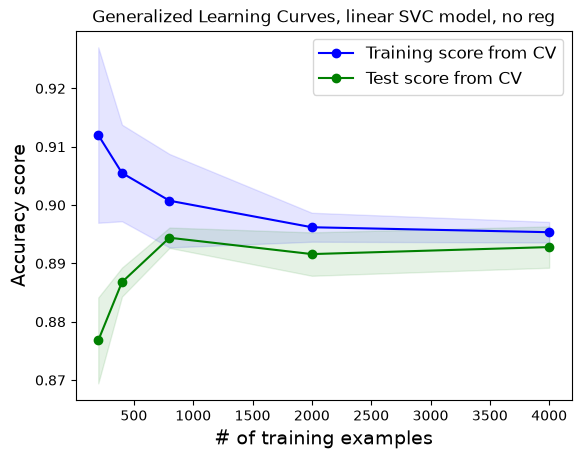

In [40]:
plot_learning_curve(piped_model, 'Generalized Learning Curves, linear SVC model, no reg',
                    features_lim, target, train_sizes = np.array([0.05,0.1,0.2,0.5,1.0]), cv = cv)

In [41]:
# Obtener predicciones usando validación cruzada
ypred_linear = cross_val_predict(
    piped_model,
    features_lim,
    target,
    cv=cv
)

#### Genere una matriz de confusión para este modelo y evalúe el desempeño del modelo a partir del resultado.

también puede usar la función [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) de `sklearn`

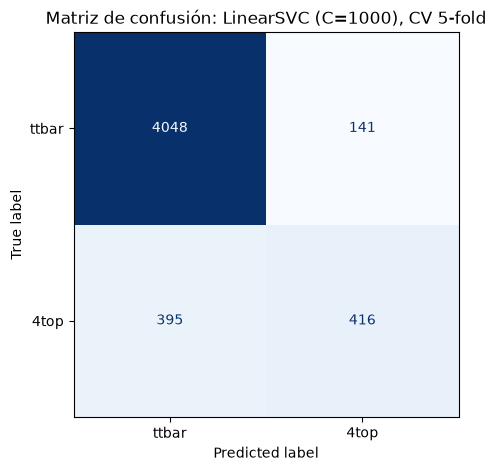

              precision    recall  f1-score   support

       ttbar       0.91      0.97      0.94      4189
        4top       0.75      0.51      0.61       811

    accuracy                           0.89      5000
   macro avg       0.83      0.74      0.77      5000
weighted avg       0.88      0.89      0.88      5000



In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cm = confusion_matrix(target, ypred_linear)

fig, ax = plt.subplots(figsize=(5,5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ttbar', '4top'])
disp.plot(cmap="Blues", ax=ax, colorbar=False)
plt.title('Matriz de confusión: LinearSVC (C=1000), CV 5-fold')
plt.show()

print(classification_report(target, ypred_linear, target_names=['ttbar', '4top']))

## Conclusiones del benchmark lineal

1. En la curva de aprendizaje, ¿los scores de entrenamiento y validación son altos o bajos?  
   ¿Están separados o son parecidos?

**Los scores de entrenamiento y validación convergen a un valor bastante similar (entre 0.89 y 0.9), lo cual podría ser un buen indicador, pues significa que el modelo no memoriza los datos de entrenamiento y listo, sino que se aplica igual de bien con los datos de prueba. Sin embargo, aunque el valor al que se llega es mayor al clasificador mayoritario, este sigue siendo un valor muy bajo. El score asimila ser alto porque la gran mayoría de los datos son del tipo ttbar, lo que lo vuelve más fácil de predecir, pero si nos fijamos en los valores obtenidos para la predicción de las 4top, observamos la deficiencia del modelo. Por ejemplo, tenemos un recall de 0.51, lo que significa que casi la mitad de los 4top fueron identificados incorrectamente.**

2. ¿La curva sugiere alto bias o alta variance?  
   Justifique usando la relación entre score de entrenamiento y validación.

**La curva sugiere alto bias. Ya que ambas curvas estan bastantes cercanas entre sí, se infiere que no hay una alta varianza, pues no hay un sobreajuste en los datos de entrenamiento que falle en los datos de prueba. Sin embargo, como ambos valores son bajos, indica la presencia de un alto bias, pues el modelo no predice bien los datos de entrenamiento y los de prueba (osea que hay un subajuste).**

3. Considerando que usamos \(C=1000\), ¿qué nos dice este resultado sobre la capacidad del modelo lineal?

**En el gráfico se observa que los scores logran converger en un punto, por lo que no hay sobreajuste (no es necesario bajar C), pero con un valor tan alto, ya casi no se puede regularizar más el modelo, por lo que subir C tampoco sería útil. Por lo tanto, C no es el culpable del rendimiento de nuestro modelo, sino que el modelo lineal no es el más óptimo para este caso, pues subajusta los datos.**

4. En la matriz de confusión, ¿el modelo detecta bien los eventos `4top` o tiende a clasificarlos como `ttbar`?

**El modelo detecta horriblemente los eventos 4top, pues como ya se observó en el recall de 0.51, casi la mitad de los 4top son clasificados como ttbar, lo que demuestra un mal rendimiento del modelo (subajuste).**

5. ¿qué métrica muestra mejor el problema con la clase minoritaria: accuracy, precision, recall o F1-score?

**La métrica que mejor muestra el problema en 4top es la mencionada anteriormente: el recall. Pues este es el que nos permite saber que la clase minoritaria (la que nos interesa mejorar) esta siendo mal clasificada. La precisión por su parte es importante, pero no nos entrega la información que nos interesa, pues el modelo minoritario tiene pocos datos en comparación al modelo mayoritario, por lo que la precisión resulta en un valor bastante bueno, cuando en realidad no se le esta midiendo el peso correcto debido a la diferencia de cantidad entre las clases.**

6. ¿El modelo lineal supera realmente los benchmarks ingenuos, o su buen desempeño se explica principalmente por el desbalance de clases?

**En comparación al benchmark ingenuos, el modelo lineal si aprende algo, y eso le permite obtener un resultado más alto que un clasificador mayoritario o aleatorio, por lo que el mejor (no buen, pero mejor) desempeño no necesariamente se explica por el desbalance de clases.**

7. ¿Qué evidencia nos indica que necesitamos un modelo más flexible que una frontera lineal?

**La evidencia se encuentra en lo mencionado en las preguntas anteriores. Observamos que ambos scores convergen a un punto similar, pero bajo (hay subajuste), y mejorar el modelo lineal no es una opción muy realista, pues ya utilizamos un valor alto de C, y aún así se obtuvo un recall demasiado bajo. Por ende, como ya no podemos mejorar el modelo lineal, necesitariamos un modelo distinto, probablemente con fronteras no planas.**

## Optimización de hiperparámetros

[`GridSearchCV`](https://scikit-learn.org/stable/modules/grid_search.html)selecciona los hiperparámetros que obtienen el mejor desempeño promedio en validación cruzada. Sin embargo, ese score puede ser optimista, porque los mismos folds de validación se usaron para elegir la mejor combinación de hiperparámetros.
Para estimar mejor el desempeño esperado en datos nuevos, se puede usar **validación cruzada anidada**. En este procedimiento, una validación cruzada interna selecciona los hiperparámetros, mientras que una validación cruzada externa evalúa el modelo seleccionado.
La idea central es no usar la misma información para elegir el modelo y para reportar su desempeño final.

La validación cruzada anidada es más rigurosa, pero no siempre vale la pena implementarla. Puede ser muy costosa, porque requiere repetir la búsqueda de hiperparámetros dentro de cada fold externo.En este notebook usaremos `GridSearchCV` para seleccionar hiperparámetros y comparar modelos, pero debemos recordar que el mejor score obtenido puede ser algo optimista. Si el objetivo fuera reportar un resultado final de investigación de manera rigurosa, sería mejor usar un conjunto de prueba independiente o validación cruzada anidada.

In [48]:
#ahora usamos la version general SVC y no la lineal, para cambiar el kernel
piped_model = make_pipeline(StandardScaler(), SVC())

piped_model.get_params() # esto nos muestra los parámetros para el scaler y el clasificador

{'memory': None,
 'steps': [('standardscaler', StandardScaler()), ('svc', SVC())],
 'transform_input': None,
 'verbose': False,
 'standardscaler': StandardScaler(),
 'svc': SVC(),
 'standardscaler__copy': True,
 'standardscaler__with_mean': True,
 'standardscaler__with_std': True,
 'svc__C': 1.0,
 'svc__break_ties': False,
 'svc__cache_size': 200,
 'svc__class_weight': None,
 'svc__coef0': 0.0,
 'svc__decision_function_shape': 'ovr',
 'svc__degree': 3,
 'svc__gamma': 'scale',
 'svc__kernel': 'rbf',
 'svc__max_iter': -1,
 'svc__probability': 'deprecated',
 'svc__random_state': None,
 'svc__shrinking': True,
 'svc__tol': 0.001,
 'svc__verbose': False}

### Podemos definir un diccionario de valores parámetros para correr la optimización

Note que esto tomará tiempo (~3 min en mi computador)

Una vez que corramos esta celda, el objeto modelo tendra atributos de "best_score_", "best_params_" y "best_estimator_", que nos da acceso al estimador óptimo y "cv_results_" que pueden ser utilizados para visualizar la performance de todos los modelo

In [50]:
%%time
#optimizando SVC, TODAVIA NO ES CV ANIDADA!

#Probamos kernel polinomial y gaussiano, parámetros gamma y degree,
# además del parámetro de regularización
parameters = {'svc__kernel':['poly', 'rbf'], \
              'svc__gamma':[0.00001,'scale', 0.01, 0.1], 'svc__C':[0.1, 1.0, 10.0, 100.0, 1000], \
              'svc__degree': [2, 4, 8]}

# CV para todos los valores de los parámetros del GridSearch
model = GridSearchCV(piped_model, parameters, cv = StratifiedKFold(n_splits=5, shuffle=True), \
                     verbose = 2, n_jobs = 4, return_train_score=True)
model.fit(features_lim,target)

print('Best params, best score:', "{:.4f}".format(model.best_score_), \
      model.best_params_)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best params, best score: 0.8952 {'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
CPU times: total: 17.4 s
Wall time: 23min 4s


####  Ahora, visualizamos los modelos en un dataframe, y los rankeamos de acuerdo a los scores de prueba.

Miraremos el promedio y desviación estándar de los test scores, el promedio de los train scores, para evaluar si son distintos  y la significancia del resultado, y fitting time, para elegir el modelo más rápido en vez del mejor modelo, si es que los scores son comparables

In [51]:
scores_lim = pd.DataFrame(model.cv_results_)

scores_lim.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_svc__C', 'param_svc__degree', 'param_svc__gamma',
       'param_svc__kernel', 'params', 'split0_test_score', 'split1_test_score',
       'split2_test_score', 'split3_test_score', 'split4_test_score',
       'mean_test_score', 'std_test_score', 'rank_test_score',
       'split0_train_score', 'split1_train_score', 'split2_train_score',
       'split3_train_score', 'split4_train_score', 'mean_train_score',
       'std_train_score'],
      dtype='str')

In [52]:
scores_lim[['params','mean_test_score','std_test_score','mean_train_score', \
            'mean_fit_time']].sort_values(by = 'mean_test_score', ascending = False)

,params,mean_test_score,std_test_score,mean_train_score,mean_fit_time
35,"{'svc__C': 1.0, 'svc__degree': 4, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.8952,0.011143,0.92185,0.583840
43,"{'svc__C': 1.0, 'svc__degree': 8, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.8952,0.011143,0.92185,0.658942
27,"{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.8952,0.011143,0.92185,0.553436
29,"{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8950,0.011296,0.90005,0.512307
31,"{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}",0.8950,0.010354,0.93925,0.855494
45,"{'svc__C': 1.0, 'svc__degree': 8, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8950,0.011296,0.90005,0.602679
39,"{'svc__C': 1.0, 'svc__degree': 4, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}",0.8950,0.010354,0.93925,0.838768
37,"{'svc__C': 1.0, 'svc__degree': 4, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8950,0.011296,0.90005,0.612784
47,"{'svc__C': 1.0, 'svc__degree': 8, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}",0.8950,0.010354,0.93925,0.709113
53,"{'svc__C': 10.0, 'svc__degree': 2, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8938,0.009368,0.91215,0.849587


Observamos que el kernel rbf es preferido constantemente, los valores de $C$ y $\gamma$ no afectan demasiado los scores. GridSearch es insensible a combinaciones de parámetros irrelevantes, por ejemplo, los tres primeros modelos son idénticos porque el grado del kernel polinomial no afecta al kernel rbf.

#### Podemos aislar un solo tipo de kernel

In [53]:
scores_lim[scores_lim['param_svc__kernel'] == 'poly'][['params','mean_test_score','std_test_score',\
                        'mean_train_score','mean_fit_time']].sort_values(by = 'mean_test_score', ascending = False)

,params,mean_test_score,std_test_score,mean_train_score,mean_fit_time
26,"{'svc__C': 1.0, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8778,0.007574,0.88180,0.607158
74,"{'svc__C': 100.0, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8778,0.010722,0.88790,16.817011
54,"{'svc__C': 10.0, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}",0.8774,0.010092,0.88755,5.752162
78,"{'svc__C': 100.0, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}",0.8772,0.011016,0.88790,62.418302
100,"{'svc__C': 1000, 'svc__degree': 2, 'svc__gamma': 0.01, 'svc__kernel': 'poly'}",0.8772,0.010107,0.88755,5.787897
102,"{'svc__C': 1000, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}",0.8772,0.010438,0.88775,533.072022
98,"{'svc__C': 1000, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8772,0.011016,0.88790,178.095302
50,"{'svc__C': 10.0, 'svc__degree': 2, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.8766,0.009769,0.88630,2.084256
52,"{'svc__C': 10.0, 'svc__degree': 2, 'svc__gamma': 0.01, 'svc__kernel': 'poly'}",0.8762,0.007332,0.87795,0.900371
6,"{'svc__C': 0.1, 'svc__degree': 2, 'svc__gamma': 0.1, 'svc__kernel': 'poly'}",0.8762,0.007332,0.87800,0.586818


In [54]:
best_model = model.best_estimator_

ypred_best = cross_val_predict(
    best_model,
    features_lim,
    target,
    cv=cv
)

**Construya la matriz de confusión para el modelo optimizado**

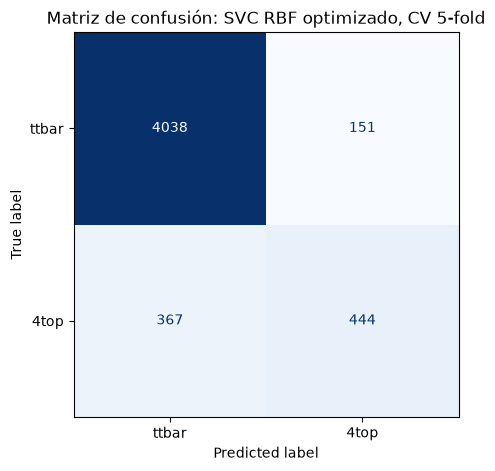

              precision    recall  f1-score   support

       ttbar       0.92      0.96      0.94      4189
        4top       0.75      0.55      0.63       811

    accuracy                           0.90      5000
   macro avg       0.83      0.76      0.79      5000
weighted avg       0.89      0.90      0.89      5000



In [56]:
cm2 = confusion_matrix(target, ypred_best)

fig2, ax2 = plt.subplots(figsize=(5,5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['ttbar', '4top'])
disp.plot(cmap="Blues", ax=ax2, colorbar=False)
plt.title('Matriz de confusión: SVC RBF optimizado, CV 5-fold')
plt.show()

print(classification_report(target, ypred_best, target_names=['ttbar', '4top']))

Preguntas:

- ¿Cuál es la accuracy del modelo optimizado?

**El accuracy del modelo optimizado es de 0.90, un valor minimamente superior al del accuracy lineal (0.89).**

- ¿Cuál es la precision para la clase 4top?

**La precisión para la clase 4top es de 0.75, manteniendose exactamente igual que en el modelo lineal**

- ¿Cuál es el recall para la clase 4top?

**El recall para la clase 4top es de 0.55, un poco mejor que el caso lineal (0.51)**

- ¿Cuál es el F1-score para la clase 4top?

**El F1-score es 0.63, también ligeramente mayor que el caso lineal (0.61)**

- ¿Qué métrica mejoró más respecto al benchmark lineal?

**La métrica que más mejoró con respecto al benchmark lineal es el recall del 4top, con una diferencia de 0.04 superior. Esta es una buena señal, pues es la métrica que considerabamos más importante. Sin embargo, su valor sigue siendo extremadamente bajo, y el resto de métricas se mantuvieron igual o aumentaron bastante poco (inclusive disminuyeron).**

- ¿Qué métrica empeoró o cambió muy poco?

**La métrica que empeoró fue el recall del evento ttbar, con una diferencia de 0.01 menor al mejor modelo. Esto puede deberse a variaciones en el modelo, pero es esperable o aceptable considerando que esa clase es mucho mayor, y lo que buscamos es mejorar el rendimiento en las predicciones de la clase menor, la cual tiene más peso debido a su poca cantidad de muestras. Por otra parte la precisión del evento 4top se mantuvo igual, y otras métricas aumentaron en valores bastantes pequeños.**

- ¿La mejora en accuracy refleja una mejora real para la clase 4top?

**Si refleja una mejora real, pero no grande. Además, para determinar si es que la mejora es real o no, se deben de observar todos los parámetros en conjunto, de esta manera identificamos problemas que podrían pasar desapercibidos, como el accuracy alto de los benchmark ingenuos.**

- ¿El modelo optimizado detecta mejor la clase minoritaria que el benchmark lineal?

**Si detecta mejor la clase minoritaria, pues el recall es ligeramente mayor al benchmark lineal, lo que significa que hay una menor cantidad de eventos 4top que fueron predichos como ttbar. Sin embargo, esta mejora es bastante pequeña, por lo que sigue sin ser un buen modelo.**

Complete la tabla de comparación


| Modelo            | Accuracy | Precision `4top` | Recall `4top` | F1-score `4top` | Comentario |
| ----------------- | -------: | ---------------: | ------------: | --------------: | ---------- |
| Benchmark lineal  |     0.89     |         0.75         |       0.51        |        0.61         |      Apenas la mitad de los eventos 4top son bien predichos      |
| Modelo optimizado |     0.90     |         0.75         |       0.55        |        0.63         |      Un poco (bsatante poco) más de la mitad de los eventos 4top son bien predichos     |

- ¿El modelo optimizado mejora todas las métricas o solo algunas?

**El modelo optimizado solo mejora algunas de las métricas, pues ya vimos que la precisión del 4top se mantuvo exactamente igual, y en el caso del ttbar hubo una métrica que incluso bajo su rendimiento. Sin embargo, esto es esperable, pues dependiendo del caso de estudio, existen métricas con mayor relevancia que otras. En este caso el modelo más óptimo trata de mejorar el resultado de predicciones sobre el evento 4top, por lo que se ajusta de manera que encuentre conveniente para lograr esto, incluso si debe de sacrificar el resultado en otras métricas que no quiera valorar tanto.**

- Si una métrica mejora pero otra empeora, ¿cómo decidiría cuál modelo es mejor?

**Lo decidiría identificando cuál es la métrica que más me interesa optimizar. Por ejemplo, en el caso anterior, debido a que el evento 4top era mucho menos recurrente que el evento ttbar, entonces al optimizar estos datos cualquier modelo podría obtener un buen resultado en la predicción de ttbar (pues es más fácil), pero no cualquiera obtendría un buen resultado en la predicción de 4top. Y como ya lo demostraron los benchmark ingenuos: la buena predicción de eventos mayoritarios no necesariamente significan un buen modelo. Para este caso, el no sería una métrica accuracy tan impactante, sino que lo sería el recall, pues lo que queremos hacer es tener la mayor cantidad de 4top bien predichos. Así que para elegir hay que saber bien como es nuestro set de datos y que es lo que queremos lograr**

- ¿La mejora justifica usar un modelo más complejo?

**Considerando costos monetarios y de tiempo (se me demoró 23min y 4 seg en ejecutar), esta mejora tan pequeña no se justificaría para usarse en vez del modelo lineal. En un caso real, podrían tenerse en mano mejores computadores, sin embargo se trabajaría con set de datos que podrían ser más grandes y que requieran soluciones mucho más complejas, por lo que se sigue manteniendo la idea de que por una mejora como esta no valdría la pena utilizar un modelo más complejo.**


#### Diagnóstico final

- ¿Qué modelo elegiría para reportar y por qué?

**Si fuese por mí, para un empresa repotaría el benchmark lineal, pues a pesar de haber resultado en valores peores que el benchmark optimizado, su coste en tiempo fue mucho menor, y su diferencia entre valores es realmente pequeña, por lo que se ahorrarían recursos y tiempo que podrían utilizarse en mejorar otros aspectos de un proyecto.**

- ¿Qué limitación importante todavía tiene el modelo?

**La limitación que tiene este set es que utiliza solamente las 4 primeras partículas registradas en cada evento, por lo que hay mucha información que pierde para poder diagnosticar de manera correcta un evento que es poco común.**

## Actividad final: mejorar el modelo

Hasta ahora usamos un conjunto limitado de features para construir y optimizar nuestros modelos. Sin embargo, el desempeño de un modelo no depende solo del algoritmo o de los hiperparámetros: también depende de la información que le entregamos.

En este dataset, cada evento contiene información de varias partículas reconstruidas. Como los eventos `4top` suelen ser más complejos que los eventos `ttbar`, es razonable pensar que usar más información del evento podría ayudar al modelo a distinguir mejor ambas clases.

**Proponga una estrategia para mejorar el modelo explorando nuevas features o usando una representación más completa de los eventos.**

Puede considerar, por ejemplo:

- incluir información de más partículas;
- usar todas las partículas disponibles;
- construir variables derivadas;
- modificar el tratamiento de valores faltantes;
- comparar distintos subconjuntos de features;
- cambiar la métrica usada para optimizar el modelo.

Luego evalúe si su propuesta mejora el desempeño respecto al modelo anterior.

In [70]:
types = [f'Type_{i}' for i in range(1, 14)]            

def col(i, k):                                         
    return features[f'P{4*(i-1)+k}']

E   = np.column_stack([col(i, 1) for i in range(1, 14)])
pt  = np.column_stack([col(i, 2) for i in range(1, 14)])
eta = np.column_stack([col(i, 3) for i in range(1, 14)])
phi = np.column_stack([col(i, 4) for i in range(1, 14)])
T = features[types]

In [71]:
features_new = pd.DataFrame(index=features.index)
features_new['MET']     = features['MET']
features_new['n_part']  = T.notna().sum(axis=1)
features_new['n_b']     = (T == 'b').sum(axis=1)
features_new['n_j']     = (T == 'j').sum(axis=1)
features_new['n_lep']   = T.isin(['e+', 'e-', 'm+', 'm-']).sum(axis=1)
features_new['HT']      = np.nansum(pt, axis=1)                     
features_new['E_tot']   = np.nansum(E, axis=1)
features_new['pt_max']  = np.nanmax(pt, axis=1)
features_new['pt_mean'] = np.nanmean(pt, axis=1)

In [72]:
px = np.nansum(pt * np.cos(phi), axis=1)
py = np.nansum(pt * np.sin(phi), axis=1)
pz = np.nansum(pt * np.sinh(eta), axis=1)
features_new['m_inv'] = np.sqrt(np.clip(features_new['E_tot']**2 - px**2 - py**2 - pz**2, 0, None))

features_new.head()

,MET,n_part,n_b,n_j,n_lep,HT,E_tot,pt_max,pt_mean,m_inv
ID,,,,,,,,,,
0,62803.5,5,1,3,1,487989.1,624088.5,128444.0,97597.82,614476.978056
1,57594.2,4,0,2,2,210963.0,570173.0,80458.3,52740.75,234913.423646
2,82313.3,5,1,4,0,256515.4,434875.9,113078.0,51303.08,278427.905302
3,30610.8,5,1,4,0,186686.9,472835.9,61383.9,37337.38,418573.853533
4,45153.1,5,0,5,0,277383.1,1182928.5,100164.0,55476.62,468503.478861


In [73]:
param_grid = {
    'svc__C':     [0.5, 1, 2, 5, 10],
    'svc__gamma': ['scale', 0.01, 0.03, 0.1],
}

grid = GridSearchCV(
    make_pipeline(StandardScaler(), SVC(kernel='rbf')),
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True,
)
grid.fit(features_new, target)

print('Mejores parámetros:', grid.best_params_)
print('Mejor score (CV):  ', round(grid.best_score_, 4))

Mejores parámetros: {'svc__C': 2, 'svc__gamma': 0.03}
Mejor score (CV):   0.9468


In [74]:
results = pd.DataFrame(grid.cv_results_)[
    ['param_svc__C', 'param_svc__gamma', 'mean_train_score',
     'mean_test_score', 'std_test_score', 'mean_fit_time']
].sort_values('mean_test_score', ascending=False)
results.head(10)

,param_svc__C,param_svc__gamma,mean_train_score,mean_test_score,std_test_score,mean_fit_time
10,2.0,0.03,0.95055,0.9468,0.007521,0.344244
6,1.0,0.03,0.95005,0.9466,0.006621,0.321696
9,2.0,0.01,0.94815,0.9464,0.007088,0.342877
5,1.0,0.01,0.94680,0.9462,0.005192,0.343871
17,10.0,0.01,0.94975,0.9462,0.008085,0.361303
14,5.0,0.03,0.95280,0.9462,0.008542,0.354159
13,5.0,0.01,0.94955,0.9462,0.006911,0.340651
1,0.5,0.01,0.94560,0.9460,0.004858,0.420022
2,0.5,0.03,0.94820,0.9460,0.004775,0.348939
18,10.0,0.03,0.95340,0.9454,0.008686,0.361719


In [75]:
ypred_grid = cross_val_predict(grid.best_estimator_, features_new, target, cv=cv)

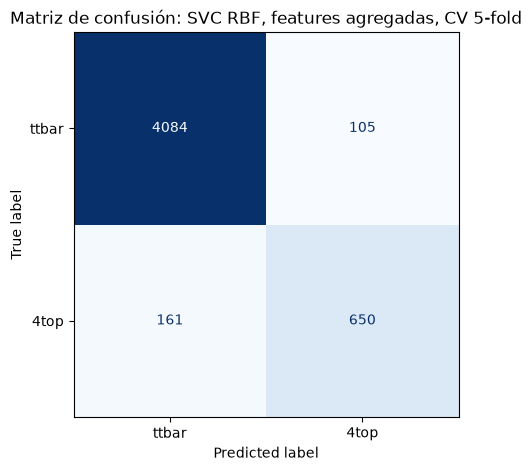

              precision    recall  f1-score   support

       ttbar       0.96      0.97      0.97      4189
        4top       0.86      0.80      0.83       811

    accuracy                           0.95      5000
   macro avg       0.91      0.89      0.90      5000
weighted avg       0.95      0.95      0.95      5000



In [76]:
cm3 = confusion_matrix(target, ypred_grid)
fig3, ax3 = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm3, display_labels=['ttbar', '4top']).plot(cmap='Blues', ax=ax3, colorbar=False)
plt.title('Matriz de confusión: SVC RBF, features agregadas, CV 5-fold')
plt.show()

print(classification_report(target, ypred_grid, target_names=['ttbar', '4top']))

### Preguntas

1. ¿Qué cambio hizo?

**Cree una nueva variable para representar a los eventos, correspondientes a n_part (número de partículas detectadas en un evento), n_b (número de bjets), n_j (número de jets), n_lep (número de leptones: mu+, mu-, e-, e+), HT (suma escalar de todos los momentums transversos), E_tot (suma escalar de todas las energías),  pt_max (valor máximo del momentum transverso) y pt_mean (valor promedio del momentum transverso). Estos nuevos features son útiles porque al ser sumas de valores, entonces las celdas NaN no aportan nada a la suma y conservamos el total de la información. Luego, se repite la busqueda de valores óptimos para los parámetros con el GridSearch, estableciendo como fijo el kernel='rbf' para evitar esperas largas en la ejecución de la búsqueda.**

2. ¿Mejoró la detección de eventos `4top`?

**Sí, mejoró bastante, pues el recall pasó de 0.55 en el mejor modelo considerando 4 partículas, a 0.8 recall. Esto quiere decir que este modelo se confunde menos e identifica bien a la gran mayoría de los eventos 4top.**

3. ¿Qué ocurrió con la matriz de confusión?

**En la matriz de confusión se observa inmediatamente que los valores no diagonales disminuyeron bastante, pues el nuevo modelo identifica de manera correcta una mayor cantidad de eventos que los modelos anteriores, de modo que los TF y TP aumentan y los FP y FN disminuyen.**

4. ¿La mejora justifica el aumento de complejidad?

**Sí, el aumento de complejidad es bajo y vale la pena. Pues fue un modelo rápido de entrenar, que utiliza menos features, y gracias a que se fijo el kernel, la búsqueda de valores óptimos no tomó mucho tiempo. Junto con todo esto, también se debe mencionar que los valores de todas las métricas en general aumentaron bastante, obteniendo un accuracy de 0.95 (0.90 fue el valor obtenido antes) y un recall de 0.80 (0.55 fue el valor obtenido antes). Esto indica que este modelo es mucho mejor que los probados antes, y además no tomó mucho tiempo de compilación.**

5. ¿Qué aprendió sobre la importancia de las features en este problema?

**Se aprendió la importancia que tienen los features para obtener un mejor resultado. Se pueden tener razones para eliminar un feature en un set de datos, pero se debe de pensar bien en las pérdidas que podría ocasionar esa acción en el resultado, pues todo feature es información adicional importante, inclusive aquellos con valor nulo o NaN, por lo que cambiar un NaN por un valor nulo puede no ser una buena idea, ya que podría resultar en un corrimiento de los resultados o una modificación en el análisis del modelo. Controlar bien los features que tenemos es importante para tener no solo un buen resultado, sino que también un uso óptimo del tiempo.**
